# NBA — Modèles Classiques

XGBoost + Réseau de neurones classique.
Pas de dépendances lourdes (pas de PennyLane).

**Cibles :**
- `home_win` → probabilité P(victoire domicile)
- `point_diff` → différentiel de points

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    accuracy_score, roc_auc_score, log_loss,
    mean_absolute_error, mean_squared_error
)
from xgboost import XGBClassifier, XGBRegressor

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

print('Imports OK')

Imports OK


In [2]:
# Chargement des données
X_train_xgb = pd.read_csv('data/nba_X_train_xgb.csv')
X_val_xgb   = pd.read_csv('data/nba_X_val_xgb.csv')
X_train_qnn = pd.read_csv('data/nba_X_train_qnn.csv').values
X_val_qnn   = pd.read_csv('data/nba_X_val_qnn.csv').values

y_train      = pd.read_csv('data/nba_y_train.csv').values.ravel()
y_val        = pd.read_csv('data/nba_y_val.csv').values.ravel()
y_train_diff = pd.read_csv('data/nba_y_train_diff.csv').values.ravel()
y_val_diff   = pd.read_csv('data/nba_y_val_diff.csv').values.ravel()

print(f'X_train_xgb : {X_train_xgb.shape}')
print(f'X_train_qnn : {X_train_qnn.shape}')
print(f'y_train     : {y_train.shape}')
print(f'Baseline (toujours domicile) : {y_val.mean():.1%}')

results = {}

X_train_xgb : (2579, 16)
X_train_qnn : (2579, 16)
y_train     : (2579,)
Baseline (toujours domicile) : 54.6%


In [3]:
def evaluate(name, y_true, y_pred_proba):
    y_pred  = (y_pred_proba >= 0.5).astype(int)
    acc     = accuracy_score(y_true, y_pred)
    auc     = roc_auc_score(y_true, y_pred_proba)
    ll      = log_loss(y_true, y_pred_proba)
    results[name] = {'accuracy': acc, 'auc': auc, 'log_loss': ll}
    print(f'\n=== {name} ===')
    print(f'  Accuracy : {acc:.1%}')
    print(f'  AUC-ROC  : {auc:.3f}')
    print(f'  Log Loss : {ll:.4f}')
    print(f'  Baseline : {y_true.mean():.1%}')
    return y_pred_proba

## 1. XGBoost

In [4]:
# Classification
xgb_clf = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=20,
    verbosity=0
)
xgb_clf.fit(
    X_train_xgb, y_train,
    eval_set=[(X_val_xgb, y_val)],
    verbose=False
)
xgb_proba = xgb_clf.predict_proba(X_val_xgb)[:, 1]
evaluate('XGBoost', y_val, xgb_proba)


=== XGBoost ===
  Accuracy : 62.9%
  AUC-ROC  : 0.679
  Log Loss : 0.6414
  Baseline : 54.6%


array([0.73625755, 0.60570556, 0.6960507 , ..., 0.66438675, 0.4963274 ,
       0.5939584 ], shape=(1309,), dtype=float32)

In [5]:
# Régression
xgb_reg = XGBRegressor(
    n_estimators=300, max_depth=4,
    learning_rate=0.05, random_state=42,
    verbosity=0
)
xgb_reg.fit(X_train_xgb, y_train_diff)
xgb_diff_pred = xgb_reg.predict(X_val_xgb)

mae  = mean_absolute_error(y_val_diff, xgb_diff_pred)
rmse = np.sqrt(mean_squared_error(y_val_diff, xgb_diff_pred))
print(f'\n=== XGBoost Régression ===')
print(f'  MAE  : {mae:.2f} points')
print(f'  RMSE : {rmse:.2f} points')


=== XGBoost Régression ===
  MAE  : 11.94 points
  RMSE : 15.15 points


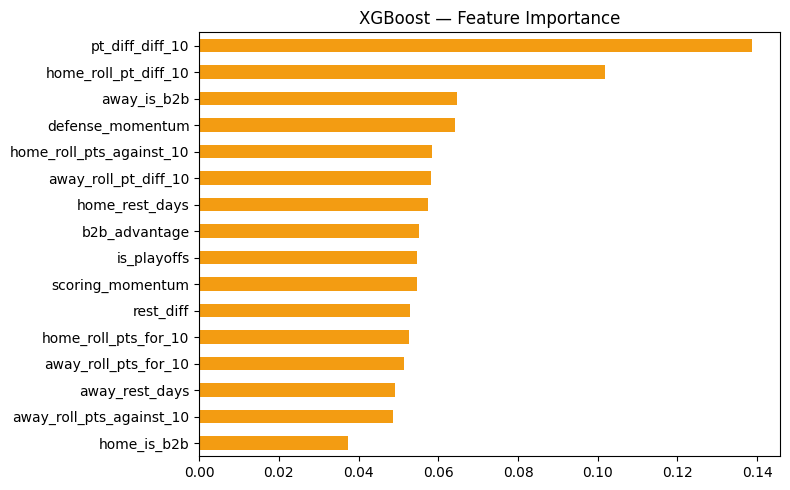

pt_diff_diff_10             0.138786
home_roll_pt_diff_10        0.101705
away_is_b2b                 0.064798
defense_momentum            0.064272
home_roll_pts_against_10    0.058376
away_roll_pt_diff_10        0.058099
home_rest_days              0.057517
b2b_advantage               0.055245
is_playoffs                 0.054680
scoring_momentum            0.054622
rest_diff                   0.052835
home_roll_pts_for_10        0.052512
away_roll_pts_for_10        0.051461
away_rest_days              0.049045
away_roll_pts_against_10    0.048614
home_is_b2b                 0.037432


In [6]:
# Feature importance
fi = pd.Series(
    xgb_clf.feature_importances_,
    index=X_train_xgb.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
fi.plot(kind='barh', color='#f39c12')
plt.title('XGBoost — Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('data/nba_xgb_importance.png', dpi=100, bbox_inches='tight')
plt.show()
print(fi.to_string())

In [7]:
# Sauvegarder
with open('data/nba_xgb_clf.pkl', 'wb') as f:
    pickle.dump(xgb_clf, f)
with open('data/nba_xgb_reg.pkl', 'wb') as f:
    pickle.dump(xgb_reg, f)
print('XGBoost sauvegardé')

XGBoost sauvegardé


## 2. Réseau de neurones classique

In [8]:
X_tr = torch.tensor(X_train_qnn, dtype=torch.float32)
y_tr = torch.tensor(y_train,     dtype=torch.float32)
X_v  = torch.tensor(X_val_qnn,   dtype=torch.float32)
y_v  = torch.tensor(y_val,       dtype=torch.float32)

train_ds = TensorDataset(X_tr, y_tr)
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)

class ClassicNN(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).squeeze()

nn_model  = ClassicNN(X_train_qnn.shape[1])
optimizer = torch.optim.Adam(nn_model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.BCELoss()

EPOCHS = 100
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    nn_model.train()
    epoch_loss = 0
    for xb, yb in train_dl:
        optimizer.zero_grad()
        pred = nn_model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    nn_model.eval()
    with torch.no_grad():
        val_loss = criterion(nn_model(X_v), y_v).item()
    train_losses.append(epoch_loss / len(train_dl))
    val_losses.append(val_loss)
    if (epoch+1) % 20 == 0:
        print(f'Epoch {epoch+1:3d} — train: {train_losses[-1]:.4f}  val: {val_losses[-1]:.4f}')

Epoch  20 — train: 0.6422  val: 0.6355
Epoch  40 — train: 0.6326  val: 0.6391
Epoch  60 — train: 0.6358  val: 0.6428
Epoch  80 — train: 0.6304  val: 0.6432
Epoch 100 — train: 0.6229  val: 0.6462


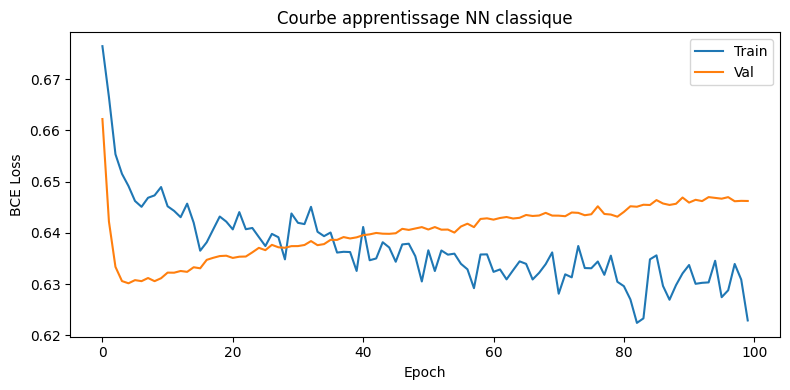

In [9]:
# Courbe apprentissage
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses,   label='Val')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title('Courbe apprentissage NN classique')
plt.legend()
plt.tight_layout()
plt.savefig('data/nba_nn_learning_curve.png', dpi=100, bbox_inches='tight')
plt.show()

In [10]:
nn_model.eval()
with torch.no_grad():
    nn_proba = nn_model(X_v).numpy()
evaluate('NN Classique', y_val, nn_proba)

torch.save(nn_model.state_dict(), 'data/nba_nn_classic.pt')
print('NN classique sauvegardé')


=== NN Classique ===
  Accuracy : 63.6%
  AUC-ROC  : 0.675
  Log Loss : 0.6462
  Baseline : 54.6%
NN classique sauvegardé


## 3. Comparaison

=== COMPARAISON ===
              accuracy     auc  log_loss
NN Classique    0.6356  0.6751    0.6462
XGBoost         0.6287  0.6786    0.6414

Baseline : 54.6%


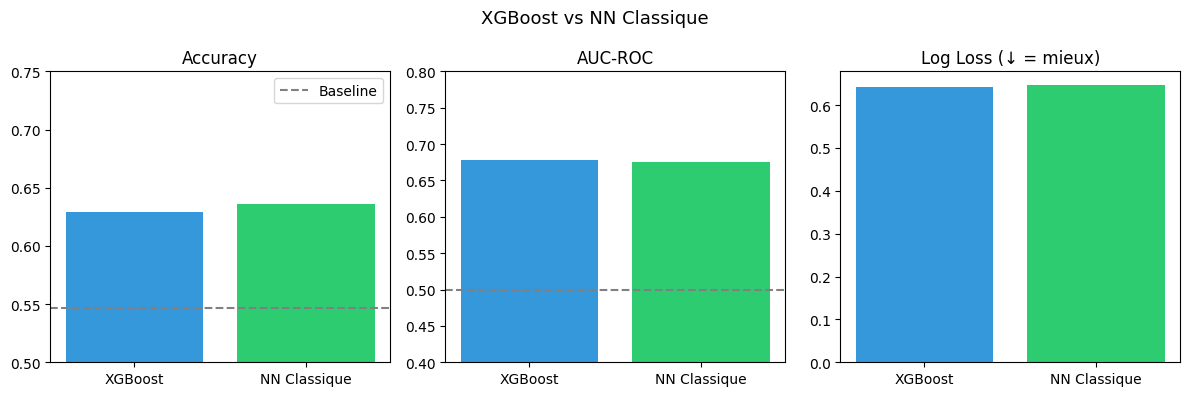

In [11]:
df_results = pd.DataFrame(results).T.sort_values('accuracy', ascending=False)
print('=== COMPARAISON ===')
print(df_results.round(4).to_string())
print(f'\nBaseline : {y_val.mean():.1%}')

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
models = list(results.keys())
colors = ['#3498db', '#2ecc71']

axes[0].bar(models, [results[m]['accuracy'] for m in models], color=colors)
axes[0].axhline(y_val.mean(), color='gray', linestyle='--', label='Baseline')
axes[0].set_title('Accuracy')
axes[0].set_ylim(0.5, 0.75)
axes[0].legend()

axes[1].bar(models, [results[m]['auc'] for m in models], color=colors)
axes[1].axhline(0.5, color='gray', linestyle='--')
axes[1].set_title('AUC-ROC')
axes[1].set_ylim(0.4, 0.8)

axes[2].bar(models, [results[m]['log_loss'] for m in models], color=colors)
axes[2].set_title('Log Loss (↓ = mieux)')

plt.suptitle('XGBoost vs NN Classique', fontsize=13)
plt.tight_layout()
plt.savefig('data/nba_model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

## 4. Fonction de prédiction

In [13]:
pd.read_csv('data/nba_team_stats_current.csv').columns.tolist()

['TEAM_ID',
 'TEAM_NAME',
 'GP',
 'W',
 'L',
 'W_PCT',
 'MIN',
 'E_OFF_RATING',
 'OFF_RATING',
 'E_DEF_RATING',
 'DEF_RATING',
 'E_NET_RATING',
 'NET_RATING',
 'AST_PCT',
 'AST_TO',
 'AST_RATIO',
 'OREB_PCT',
 'DREB_PCT',
 'REB_PCT',
 'TM_TOV_PCT',
 'EFG_PCT',
 'TS_PCT',
 'E_PACE',
 'PACE',
 'PACE_PER40',
 'POSS',
 'PIE',
 'GP_RANK',
 'W_RANK',
 'L_RANK',
 'W_PCT_RANK',
 'MIN_RANK',
 'OFF_RATING_RANK',
 'DEF_RATING_RANK',
 'NET_RATING_RANK',
 'AST_PCT_RANK',
 'AST_TO_RANK',
 'AST_RATIO_RANK',
 'OREB_PCT_RANK',
 'DREB_PCT_RANK',
 'REB_PCT_RANK',
 'TM_TOV_PCT_RANK',
 'EFG_PCT_RANK',
 'TS_PCT_RANK',
 'PACE_RANK',
 'PIE_RANK']

In [19]:
def predict_game(home_team, away_team, model='xgboost'):
    """
    Prédit le résultat d'un match NBA depuis les stats actuelles.
    
    home_team / away_team : trigramme NBA ex 'LAL', 'GSW', 'BOS'
    model : 'xgboost' | 'nn'
    """
    team_stats = pd.read_csv('data/nba_team_stats_current.csv')

    home = team_stats[team_stats['TEAM_NAME'].str.contains(home_team, case=False)]
    away = team_stats[team_stats['TEAM_NAME'].str.contains(away_team, case=False)]

    if home.empty or away.empty:
        print(f'Équipes disponibles : {sorted(team_stats["TEAM_ABBREVIATION"].tolist())}')
        raise ValueError(f'Équipe introuvable : {home_team} ou {away_team}')

    home = home.iloc[0]
    away = away.iloc[0]

    with open('data/nba_features_xgb.pkl', 'rb') as f:
        features_xgb = pickle.load(f)
    with open('data/nba_features_qnn.pkl', 'rb') as f:
        features_qnn = pickle.load(f)
    with open('data/nba_scaler_xgb.pkl', 'rb') as f:
        scaler_xgb = pickle.load(f)
    with open('data/nba_scaler_qnn.pkl', 'rb') as f:
        scaler_qnn = pickle.load(f)

    STAT_MAP = {
        'pt_diff_diff_10':          home.get('NET_RATING', 0) - away.get('NET_RATING', 0),
        'home_roll_pt_diff_10':     home.get('NET_RATING', 0),
        'away_roll_pt_diff_10':     away.get('NET_RATING', 0),
        'home_roll_pts_for_10':     home.get('OFF_RATING', 110),
        'away_roll_pts_for_10':     away.get('OFF_RATING', 110),
        'home_roll_pts_against_10': home.get('DEF_RATING', 110),
        'away_roll_pts_against_10': away.get('DEF_RATING', 110),
        'scoring_momentum':         home.get('OFF_RATING', 110) - away.get('OFF_RATING', 110),
        'defense_momentum':         away.get('DEF_RATING', 110) - home.get('DEF_RATING', 110),
        'home_rest_days':           2,
        'away_rest_days':           2,
        'home_is_b2b':              0,
        'away_is_b2b':              0,
        'rest_diff':                0,
        'b2b_advantage':            0,
        'is_playoffs':              0,
    }

    if model == 'xgboost':
        x = np.array([STAT_MAP.get(f, 0) for f in features_xgb]).reshape(1, -1)
        x_scaled = scaler_xgb.transform(x)
        p_home = xgb_clf.predict_proba(x_scaled)[0, 1]
    else:
        x = np.array([STAT_MAP.get(f, 0) for f in features_qnn]).reshape(1, -1)
        x_scaled = np.clip(scaler_qnn.transform(x), -np.pi, np.pi)
        x_t = torch.tensor(x_scaled, dtype=torch.float32)
        nn_model.eval()
        with torch.no_grad():
            p_home = nn_model(x_t).item()
    p_away  = 1 - p_home
    winner  = home_team if p_home > 0.5 else away_team
    conf    = max(p_home, p_away)

    print(f'\n🏀 {home_team} (dom.) vs {away_team} (ext.)')
    print(f'   P({home_team} gagne) = {p_home:.1%}')
    print(f'   P({away_team} gagne) = {p_away:.1%}')
    print(f'   → {winner} ({conf:.1%} de confiance) [modèle: {model}]')

    return {'home': home_team, 'away': away_team,
            'p_home': round(p_home, 3), 'p_away': round(p_away, 3),
            'winner': winner, 'confidence': round(conf, 3)}

# Test
predict_game('Lakers', 'Warriors', model='xgboost')
predict_game('Lakers', 'Warriors', model='nn')
predict_game('Celtics', 'Heat', model='xgboost')
predict_game('Nuggets', 'Warriors', model='xgboost')


🏀 Lakers (dom.) vs Warriors (ext.)
   P(Lakers gagne) = 58.4%
   P(Warriors gagne) = 41.6%
   → Lakers (58.4% de confiance) [modèle: xgboost]

🏀 Lakers (dom.) vs Warriors (ext.)
   P(Lakers gagne) = 62.6%
   P(Warriors gagne) = 37.4%
   → Lakers (62.6% de confiance) [modèle: nn]

🏀 Celtics (dom.) vs Heat (ext.)
   P(Celtics gagne) = 66.0%
   P(Heat gagne) = 34.0%
   → Celtics (66.0% de confiance) [modèle: xgboost]

🏀 Nuggets (dom.) vs Warriors (ext.)
   P(Nuggets gagne) = 60.1%
   P(Warriors gagne) = 39.9%
   → Nuggets (60.1% de confiance) [modèle: xgboost]


{'home': 'Nuggets',
 'away': 'Warriors',
 'p_home': np.float32(0.601),
 'p_away': np.float32(0.399),
 'winner': 'Nuggets',
 'confidence': np.float32(0.601)}

In [17]:
team_stats = pd.read_csv('data/nba_team_stats_current.csv')
lakers = team_stats[team_stats['TEAM_NAME'].str.contains('Lakers', case=False)]
print(lakers[['TEAM_NAME', 'NET_RATING', 'OFF_RATING', 'DEF_RATING', 
               'PACE', 'EFG_PCT', 'W_PCT', 'PIE']].to_string())


             TEAM_NAME  NET_RATING  OFF_RATING  DEF_RATING   PACE  EFG_PCT  W_PCT    PIE
13  Los Angeles Lakers         1.5       117.0       115.5  99.22    0.573  0.646  0.513


In [21]:
import pennylane as qml
from pennylane import numpy as pnp
import pickle

# Charger les features QNN
with open('data/nba_features_qnn.pkl', 'rb') as f:
    features_qnn = pickle.load(f)

X_train_qnn = pd.read_csv('data/nba_X_train_qnn.csv').values
X_val_qnn   = pd.read_csv('data/nba_X_val_qnn.csv').values

N_QUBITS = 8
N_LAYERS = 3

features_qnn_8 = features_qnn[:8]
X_train_8 = X_train_qnn[:, :8]
X_val_8   = X_val_qnn[:, :8]

print(f'Qubits  : {N_QUBITS}')
print(f'Features: {features_qnn_8}')

dev = qml.device('default.qubit', wires=N_QUBITS)

@qml.qnode(dev, interface='torch')
def quantum_circuit(features, weights):
    qml.AngleEmbedding(features, wires=range(N_QUBITS), rotation='Y')
    qml.BasicEntanglerLayers(weights, wires=range(N_QUBITS))
    return qml.expval(qml.PauliZ(0))

print(qml.draw(quantum_circuit)(
    X_train_8[0],
    np.random.uniform(0, np.pi, (N_LAYERS, N_QUBITS))
))

Qubits  : 8
Features: ['home_roll_pts_for_10', 'away_roll_pts_for_10', 'home_roll_pts_against_10', 'away_roll_pts_against_10', 'home_roll_pt_diff_10', 'away_roll_pt_diff_10', 'pt_diff_diff_10', 'scoring_momentum']
0: ─╭AngleEmbedding(M0)─╭BasicEntanglerLayers(M1)─┤  <Z>
1: ─├AngleEmbedding(M0)─├BasicEntanglerLayers(M1)─┤     
2: ─├AngleEmbedding(M0)─├BasicEntanglerLayers(M1)─┤     
3: ─├AngleEmbedding(M0)─├BasicEntanglerLayers(M1)─┤     
4: ─├AngleEmbedding(M0)─├BasicEntanglerLayers(M1)─┤     
5: ─├AngleEmbedding(M0)─├BasicEntanglerLayers(M1)─┤     
6: ─├AngleEmbedding(M0)─├BasicEntanglerLayers(M1)─┤     
7: ─╰AngleEmbedding(M0)─╰BasicEntanglerLayers(M1)─┤     

M0 = 
[-1.95182757  1.27649295 -0.69851977  1.33977512 -1.04785206 -0.09582716
 -0.66328152 -2.41709793]
M1 = 
[[1.70347423 1.02633461 0.18725311 2.17060929 2.52932591 1.20581646
  1.12677658 2.01557687]
 [2.80097368 1.7659393  0.59901891 2.61970875 1.12672094 2.89543678
  1.82099014 0.71591933]
 [0.89165867 0.16428993 2.252637

In [22]:
# Modèle hybride
class HybridQNN(nn.Module):
    def __init__(self, n_qubits, n_layers):
        super().__init__()
        self.weights = nn.Parameter(
            torch.tensor(
                np.random.uniform(0, np.pi, (n_layers, n_qubits)),
                dtype=torch.float32
            )
        )
        self.scaling = nn.Parameter(torch.ones(1))
        self.bias    = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        out = torch.stack([
            quantum_circuit(x[i], self.weights)
            for i in range(x.shape[0])
        ]).float()
        return torch.sigmoid(self.scaling * out + self.bias)

qnn_model = HybridQNN(N_QUBITS, N_LAYERS)

# Entraînement sur sous-ensemble pour commencer
N_SAMPLE   = 500
EPOCHS_QNN = 10
BATCH_SIZE = 64

X_tr_q = torch.tensor(X_train_8[:N_SAMPLE], dtype=torch.float32)
y_tr_q = torch.tensor(y_train[:N_SAMPLE],   dtype=torch.float32)
X_v_q  = torch.tensor(X_val_8[:200],        dtype=torch.float32)
y_v_q  = torch.tensor(y_val[:200],          dtype=torch.float32)

train_ds_q = TensorDataset(X_tr_q, y_tr_q)
train_dl_q = DataLoader(train_ds_q, batch_size=BATCH_SIZE, shuffle=True)

optimizer_q = torch.optim.Adam(qnn_model.parameters(), lr=0.01)
criterion_q = nn.BCELoss()

print(f'Entraînement QNN : {N_SAMPLE} samples, {EPOCHS_QNN} epochs')
print(f'Estimation : ~{EPOCHS_QNN * (N_SAMPLE//BATCH_SIZE) * 3:.0f} secondes')

for epoch in range(EPOCHS_QNN):
    qnn_model.train()
    epoch_loss = 0
    for xb, yb in train_dl_q:
        optimizer_q.zero_grad()
        pred = qnn_model(xb)
        loss = criterion_q(pred, yb)
        loss.backward()
        optimizer_q.step()
        epoch_loss += loss.item()
    
    qnn_model.eval()
    with torch.no_grad():
        val_loss = criterion_q(qnn_model(X_v_q), y_v_q).item()
    
    print(f'Epoch {epoch+1:2d}/{EPOCHS_QNN} — train: {epoch_loss/len(train_dl_q):.4f}  val: {val_loss:.4f}')

Entraînement QNN : 500 samples, 10 epochs
Estimation : ~210 secondes
Epoch  1/10 — train: 0.6899  val: 0.6872
Epoch  2/10 — train: 0.6809  val: 0.6825
Epoch  3/10 — train: 0.6754  val: 0.6790
Epoch  4/10 — train: 0.6719  val: 0.6768
Epoch  5/10 — train: 0.6695  val: 0.6756
Epoch  6/10 — train: 0.6661  val: 0.6751
Epoch  7/10 — train: 0.6652  val: 0.6750
Epoch  8/10 — train: 0.6642  val: 0.6750
Epoch  9/10 — train: 0.6632  val: 0.6750
Epoch 10/10 — train: 0.6636  val: 0.6751


In [23]:
qnn_model.eval()
with torch.no_grad():
    qnn_proba = qnn_model(X_v_q).numpy()

evaluate('QNN (8 qubits, 500 samples)', y_val[:200], qnn_proba)


=== QNN (8 qubits, 500 samples) ===
  Accuracy : 59.0%
  AUC-ROC  : 0.571
  Log Loss : 0.6751
  Baseline : 59.0%


array([0.6089773 , 0.59648055, 0.60310584, 0.5921308 , 0.6035519 ,
       0.5454229 , 0.6012826 , 0.6020251 , 0.6176475 , 0.5982122 ,
       0.6050883 , 0.5940388 , 0.59972084, 0.60167694, 0.59048605,
       0.61244035, 0.574542  , 0.6095383 , 0.60210115, 0.601562  ,
       0.6046964 , 0.6028366 , 0.6014281 , 0.6238838 , 0.6606026 ,
       0.6093538 , 0.5992942 , 0.6017984 , 0.6050464 , 0.5673186 ,
       0.64652973, 0.5993425 , 0.6073328 , 0.6051793 , 0.60270655,
       0.6024546 , 0.60273504, 0.6400232 , 0.60532373, 0.60209286,
       0.60181665, 0.6008658 , 0.5830581 , 0.57471246, 0.60263646,
       0.5765142 , 0.6222093 , 0.63774717, 0.60325307, 0.64803225,
       0.60002965, 0.60590035, 0.601537  , 0.60279953, 0.59843767,
       0.6384824 , 0.6017191 , 0.60750294, 0.59989953, 0.6022033 ,
       0.6192944 , 0.60456866, 0.5995009 , 0.60033464, 0.6031869 ,
       0.6070648 , 0.6019394 , 0.6016658 , 0.5952649 , 0.6016396 ,
       0.6195345 , 0.59181404, 0.6012782 , 0.60127914, 0.60044

In [26]:
import pennylane as qml
import pickle

with open('data/nba_features_qnn.pkl', 'rb') as f:
    features_qnn = pickle.load(f)

X_train_qnn = pd.read_csv('data/nba_X_train_qnn.csv').values
X_val_qnn   = pd.read_csv('data/nba_X_val_qnn.csv').values

N_QUBITS = 8
N_LAYERS = 3

X_train_8 = X_train_qnn[:, :8]
X_val_8   = X_val_qnn[:, :8]

dev = qml.device('default.qubit', wires=N_QUBITS)

@qml.qnode(dev, interface='torch')
def quantum_circuit(features, weights):
    qml.AngleEmbedding(features, wires=range(N_QUBITS), rotation='Y')
    qml.BasicEntanglerLayers(weights, wires=range(N_QUBITS))
    return qml.expval(qml.PauliZ(0))

class HybridQNNv2(nn.Module):
    def __init__(self, n_qubits, n_layers):
        super().__init__()
        self.classical = nn.Sequential(
            nn.Linear(n_qubits, n_qubits),
            nn.Tanh(),
        )
        self.weights = nn.Parameter(
            torch.tensor(
                np.random.uniform(0, np.pi, (n_layers, n_qubits)),
                dtype=torch.float32
            )
        )
        self.scaling = nn.Parameter(torch.ones(1))
        self.bias    = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        x_prep = self.classical(x) * np.pi
        out = torch.stack([
            quantum_circuit(x_prep[i], self.weights)
            for i in range(x.shape[0])
        ]).float()
        return torch.sigmoid(self.scaling * out + self.bias)

qnn_model = HybridQNNv2(N_QUBITS, N_LAYERS)

N_SAMPLE   = 2578
EPOCHS_QNN = 60
BATCH_SIZE = 128
LR_QNN     = 0.01

X_tr_q = torch.tensor(X_train_8[:N_SAMPLE], dtype=torch.float32)
y_tr_q = torch.tensor(y_train[:N_SAMPLE],   dtype=torch.float32)
X_v_q  = torch.tensor(X_val_8[:500],        dtype=torch.float32)
y_v_q  = torch.tensor(y_val[:500],          dtype=torch.float32)

train_ds_q = TensorDataset(X_tr_q, y_tr_q)
train_dl_q = DataLoader(train_ds_q, batch_size=BATCH_SIZE, shuffle=True)

optimizer_q = torch.optim.Adam(qnn_model.parameters(), lr=LR_QNN)
criterion_q = nn.BCELoss()

best_val_loss = float('inf')
patience      = 10
no_improve    = 0

print(f'HybridQNNv2 : {N_QUBITS} qubits, {N_LAYERS} layers, {N_SAMPLE} samples')
print(f'Early stopping patience : {patience} epochs')

for epoch in range(EPOCHS_QNN):
    qnn_model.train()
    epoch_loss = 0
    for xb, yb in train_dl_q:
        optimizer_q.zero_grad()
        pred = qnn_model(xb)
        loss = criterion_q(pred, yb)
        loss.backward()
        optimizer_q.step()
        epoch_loss += loss.item()

    qnn_model.eval()
    with torch.no_grad():
        val_loss = criterion_q(qnn_model(X_v_q), y_v_q).item()

    is_best = val_loss < best_val_loss
    if is_best:
        best_val_loss = val_loss
        torch.save(qnn_model.state_dict(), 'data/nba_qnn_v2_best.pt')
        no_improve = 0
    else:
        no_improve += 1

    print(f'Epoch {epoch+1:2d}/{EPOCHS_QNN} — '
          f'train: {epoch_loss/len(train_dl_q):.4f}  val: {val_loss:.4f}'
          + (' ← best' if is_best else f' (patience {no_improve}/{patience})'))

    if no_improve >= patience:
        print(f'\nEarly stopping à l\'epoch {epoch+1}')
        break

# Recharger le meilleur modèle
qnn_model.load_state_dict(torch.load('data/nba_qnn_v2_best.pt'))
print(f'\nMeilleur modèle rechargé — val_loss: {best_val_loss:.4f}')

# Évaluation finale
qnn_model.eval()
with torch.no_grad():
    qnn_proba = qnn_model(X_v_q).numpy()

evaluate('QNN Hybride v2 (best)', y_val[:500], qnn_proba)
torch.save(qnn_model.state_dict(), 'data/nba_qnn_v2_weights.pt')
print('QNN v2 sauvegardé')

HybridQNNv2 : 8 qubits, 3 layers, 2578 samples
Early stopping patience : 10 epochs
Epoch  1/60 — train: 0.6858  val: 0.6810 ← best
Epoch  2/60 — train: 0.6725  val: 0.6723 ← best
Epoch  3/60 — train: 0.6620  val: 0.6723 ← best
Epoch  4/60 — train: 0.6635  val: 0.6571 ← best
Epoch  5/60 — train: 0.6542  val: 0.6535 ← best
Epoch  6/60 — train: 0.6533  val: 0.6412 ← best
Epoch  7/60 — train: 0.6481  val: 0.6338 ← best
Epoch  8/60 — train: 0.6480  val: 0.6415 (patience 1/10)
Epoch  9/60 — train: 0.6502  val: 0.6427 (patience 2/10)
Epoch 10/60 — train: 0.6445  val: 0.6397 (patience 3/10)
Epoch 11/60 — train: 0.6501  val: 0.6439 (patience 4/10)
Epoch 12/60 — train: 0.6422  val: 0.6340 (patience 5/10)
Epoch 13/60 — train: 0.6474  val: 0.6401 (patience 6/10)
Epoch 14/60 — train: 0.6440  val: 0.6368 (patience 7/10)
Epoch 15/60 — train: 0.6437  val: 0.6461 (patience 8/10)
Epoch 16/60 — train: 0.6466  val: 0.6390 (patience 9/10)
Epoch 17/60 — train: 0.6491  val: 0.6309 ← best
Epoch 18/60 — train: